=== Blind Test for Inter-Zone Empty Travel Time Model ===
Testing on completely unseen PROBE-202412 data
Loading trained model and artifacts...
✅ Model and artifacts loaded successfully!
Model type: XGBoost Regressor
Training MAE: 7.238 minutes
Training R²: 0.6747
Features: 19

Loading test data from /Users/jul/Desktop/uni/Data Analytics/PROBE-202412...
Loading: 20241201.csv.out
Loading: 20241202.csv.out
Loading: 20241203.csv.out
Loading: 20241204.csv.out
Loading: 20241205.csv.out
Loading: 20241206.csv.out
Loading: 20241207.csv.out
Loading: 20241208.csv.out
Loading: 20241209.csv.out
Loading: 20241210.csv.out
✅ Loaded 10 files with 18,926,337 GPS points
After Bangkok filtering: 14,796,104 GPS points
Date range: 2022-03-16 12:54:31 to 2024-12-10 23:59:28
Unique vehicles: 3063

=== Processing Test Data ===
Extracting empty travel segments from test data...
Processing 3063 vehicles...
Extracted 120375 empty travel segments from test data
Calculating zone features for test data...
Adding tr

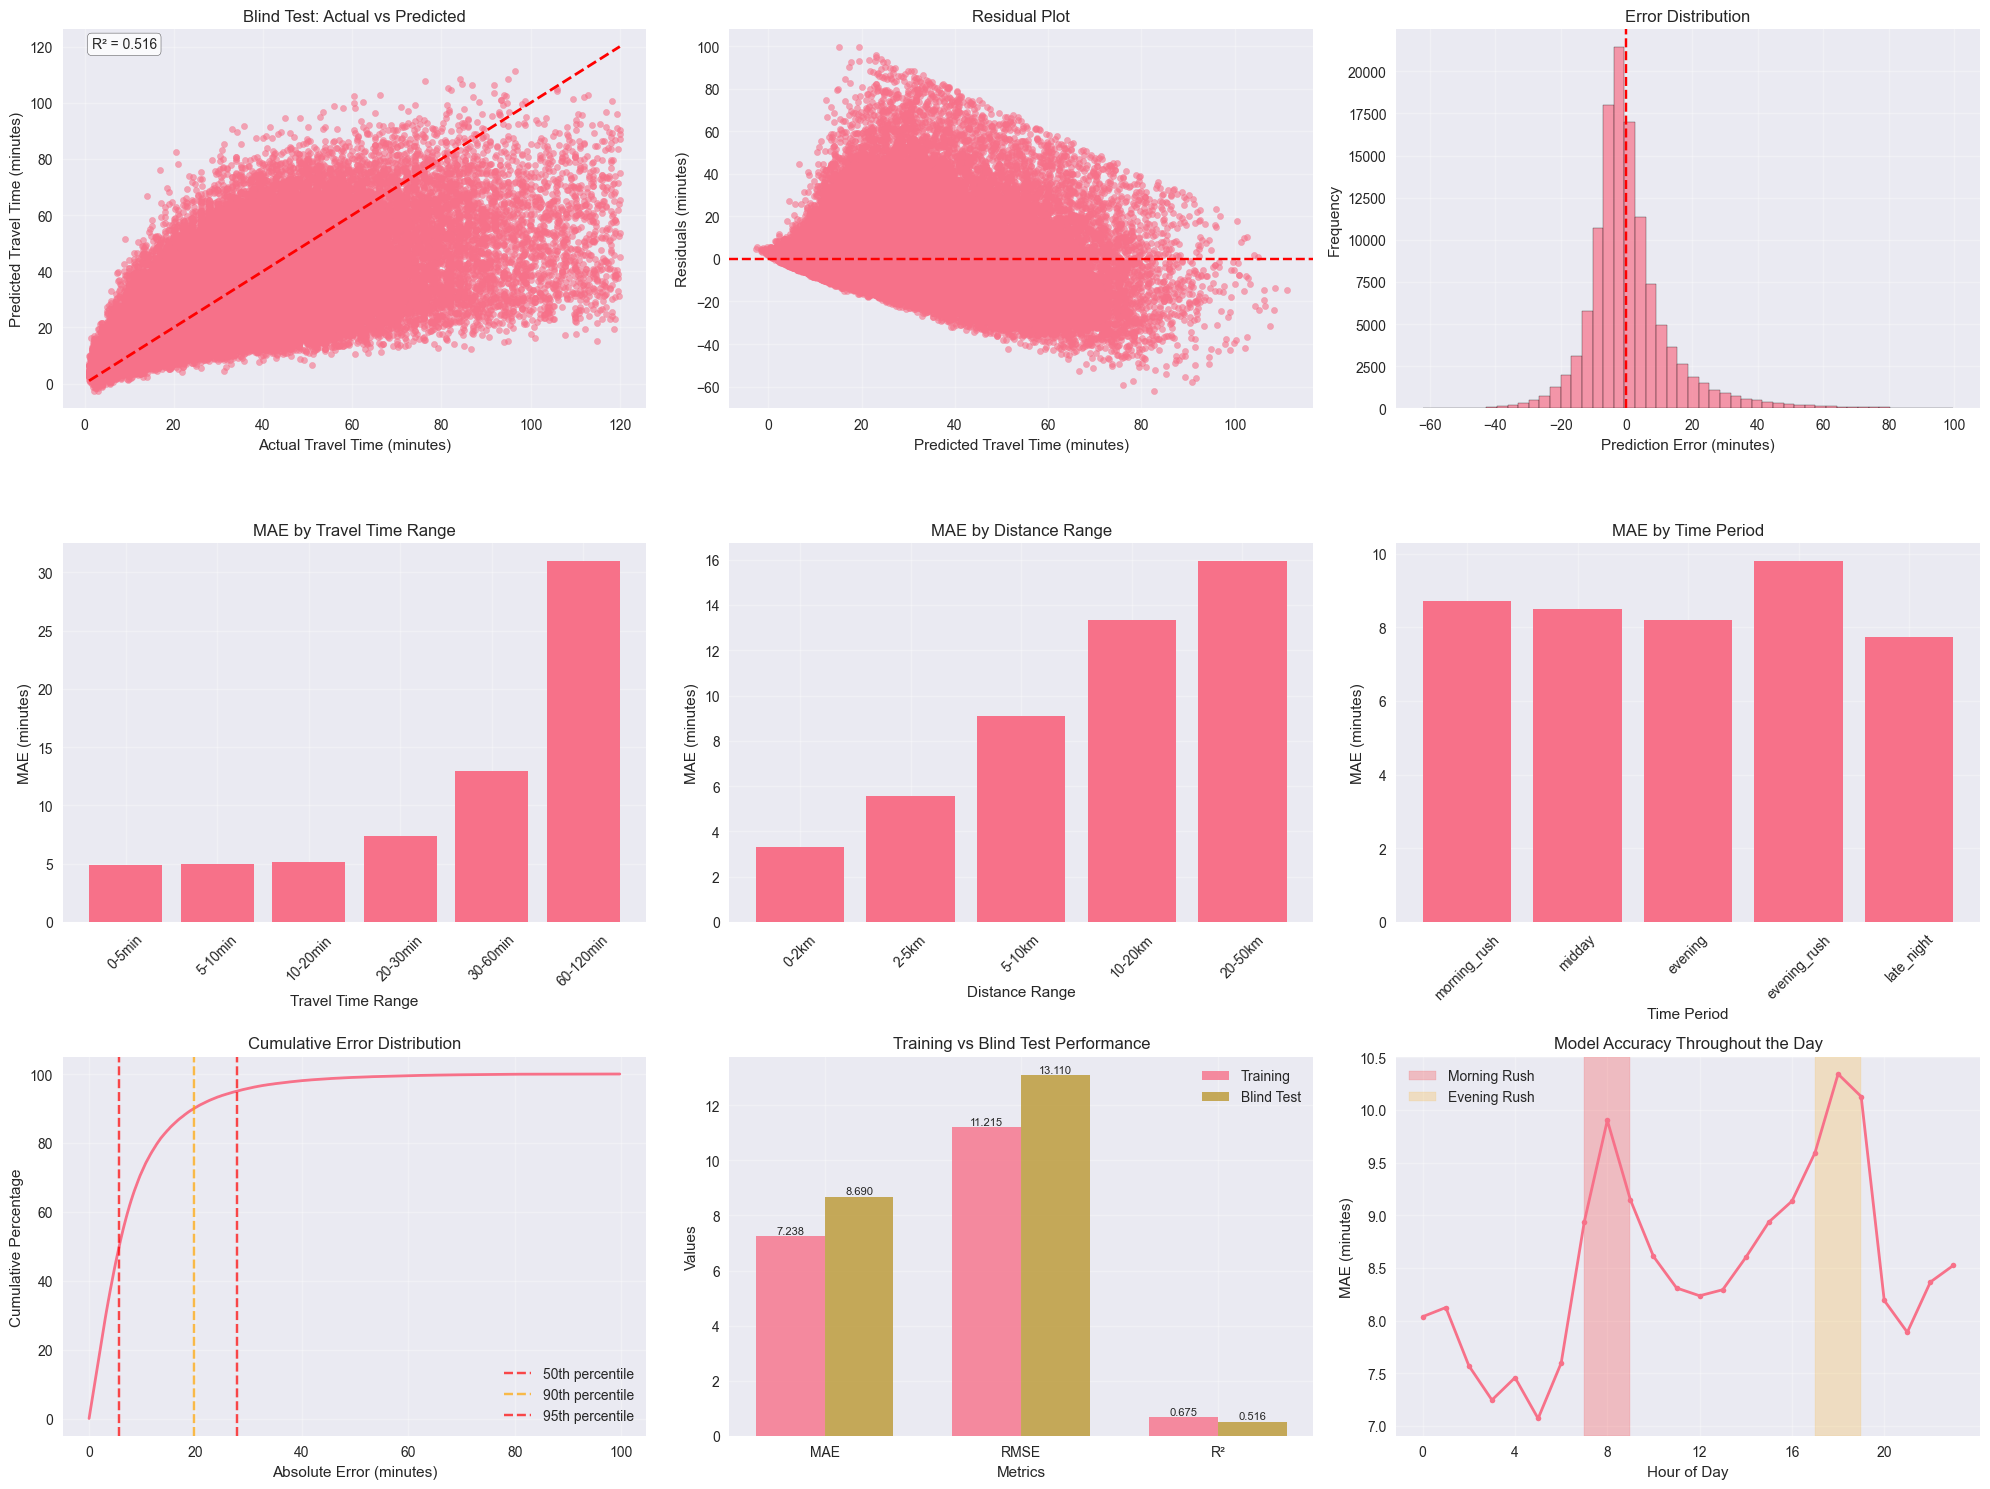


=== Detailed Error Analysis ===
Error Percentiles (Absolute Error):
  50th percentile: 5.66 minutes
  75th percentile: 10.95 minutes
  90th percentile: 19.73 minutes
  95th percentile: 27.72 minutes
  99th percentile: 49.41 minutes

Worst Predictions Analysis:
Top 10 Worst Predictions:
 1. Actual: 117.0min, Predicted:  24.7min, Error:   92.3min, Distance: 14.0km, Hour:  1
 2. Actual: 118.2min, Predicted:  25.5min, Error:   92.7min, Distance: 16.9km, Hour:  9
 3. Actual: 112.2min, Predicted:  19.5min, Error:   92.8min, Distance: 12.5km, Hour:  4
 4. Actual: 116.0min, Predicted:  22.9min, Error:   93.1min, Distance: 10.2km, Hour: 14
 5. Actual: 115.0min, Predicted:  21.6min, Error:   93.4min, Distance: 13.4km, Hour:  0
 6. Actual: 118.2min, Predicted:  24.2min, Error:   94.0min, Distance: 10.4km, Hour: 16
 7. Actual: 117.9min, Predicted:  23.2min, Error:   94.7min, Distance: 13.1km, Hour:  5
 8. Actual: 119.0min, Predicted:  23.0min, Error:   96.0min, Distance: 10.4km, Hour: 20
 9. Actu

In [1]:
# %%
# Blind Test for Inter-Zone Empty Travel Time Prediction Model
# Testing on completely unseen PROBE-202412 data

import pandas as pd
import numpy as np
import os
import h3
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from concurrent.futures import ThreadPoolExecutor
from multiprocessing import cpu_count
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=== Blind Test for Inter-Zone Empty Travel Time Model ===")
print("Testing on completely unseen PROBE-202412 data")

# %%
# Configuration
TEST_DATA_PATH = '/Users/jul/Desktop/uni/Data Analytics/PROBE-202412'
BKK_REGION_BOUNDS = {
    'min_lat': 13.4,
    'max_lat': 14.2,
    'min_lon': 99.9,
    'max_lon': 101.3
}

columns = [
    'VehicleID',
    'gpsvalid',
    'lat',
    'lon',
    'timestamp',
    'speed',
    'heading',
    'for_hire_light',
    'engine_acc'
]

# %%
# Load trained model and artifacts
print("Loading trained model and artifacts...")

try:
    model = joblib.load('xgboost_inter_zone_model.pkl')
    feature_names = joblib.load('model_feature_names.pkl')
    with open('model_metadata.json', 'r') as f:
        model_metadata = json.load(f)
    print("✅ Model and artifacts loaded successfully!")
    print(f"Model type: {model_metadata['model_type']}")
    print(f"Training MAE: {model_metadata['test_mae']:.3f} minutes")
    print(f"Training R²: {model_metadata['test_r2']:.4f}")
    print(f"Features: {model_metadata['feature_count']}")
except FileNotFoundError as e:
    print(f"❌ Error loading model artifacts: {e}")
    print("Make sure you have trained the model first!")
    exit()

# %%
# Load test data from PROBE-202412
print(f"\nLoading test data from {TEST_DATA_PATH}...")

test_dfs = []
file_count = 0
max_files = 10  # Limit to 10 files as requested

for filename in sorted(os.listdir(TEST_DATA_PATH)):
    if filename.endswith('.csv.out') and file_count < max_files:
        file_path = os.path.join(TEST_DATA_PATH, filename)
        print(f"Loading: {filename}")
        
        df = pd.read_csv(file_path, names=columns)
        test_dfs.append(df)
        file_count += 1

if len(test_dfs) == 0:
    print("❌ No test files found!")
    exit()

# Combine all test dataframes
test_df = pd.concat(test_dfs, ignore_index=True)
print(f"✅ Loaded {len(test_dfs)} files with {len(test_df):,} GPS points")

# Filter to Bangkok region
test_df = test_df[
    (test_df['lat'] >= BKK_REGION_BOUNDS['min_lat']) &
    (test_df['lat'] <= BKK_REGION_BOUNDS['max_lat']) &
    (test_df['lon'] >= BKK_REGION_BOUNDS['min_lon']) &
    (test_df['lon'] <= BKK_REGION_BOUNDS['max_lon'])
].reset_index(drop=True)

test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])

print(f"After Bangkok filtering: {len(test_df):,} GPS points")
print(f"Date range: {test_df['timestamp'].min()} to {test_df['timestamp'].max()}")
print(f"Unique vehicles: {test_df['VehicleID'].nunique()}")

# %%
# Feature Engineering Functions (same as training)

def get_h3_batch(coords_batch, h3_res=7):
    results = []
    for lat, lon in coords_batch:
        if pd.isna(lat) or pd.isna(lon):
            results.append(None)
        else:
            try:
                if hasattr(h3, 'geo_to_h3'):
                    results.append(h3.geo_to_h3(lat, lon, h3_res))
                else:
                    results.append(h3.latlng_to_cell(lat, lon, h3_res))
            except:
                results.append(None)
    return results

def haversine_distance1(lon1, lat1, lon2, lat2):
    """
    Calculate the great-circle distance between two points 
    on the earth (specified in decimal degrees).
    """
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    r = 6371 # Radius of earth in kilometers.
    return c * r

def assign_h3_zones_parallel(df, lat_col='lat', lon_col='lon', h3_res=7):
    from functools import partial
    
    df = df.copy()
    coords = list(zip(df[lat_col], df[lon_col]))
    
    batch_size = len(coords) // cpu_count() + 1
    batches = [coords[i:i+batch_size] for i in range(0, len(coords), batch_size)]
    
    h3_func = partial(get_h3_batch, h3_res=h3_res)
    
    with ThreadPoolExecutor(max_workers=cpu_count()) as executor:
        results = list(executor.map(h3_func, batches))
    
    h3_zones = [zone for batch_result in results for zone in batch_result]
    df['h3_zone'] = h3_zones
    
    return df

def process_vehicle_trips(vehicle_data_tuple):
    vehicle_id, vehicle_data = vehicle_data_tuple
    vehicle_data = vehicle_data.sort_values('timestamp').reset_index(drop=True)
    
    if len(vehicle_data) < 2:
        return []
        
    empty_trips = []
    
    vehicle_data['prev_for_hire'] = vehicle_data['for_hire_light'].shift(1)
    
    empty_starts = vehicle_data[
        ((vehicle_data['for_hire_light'] == 1) & (vehicle_data['prev_for_hire'] == 0)) |
        ((vehicle_data['for_hire_light'] == 1) & (vehicle_data['prev_for_hire'].isna()))
    ].copy()
    
    empty_ends = vehicle_data[
        (vehicle_data['for_hire_light'] == 0) & (vehicle_data['prev_for_hire'] == 1)
    ].copy()
    
    for _, start_row in empty_starts.iterrows():
        start_time = start_row['timestamp']
        start_zone = start_row['h3_zone']
        
        if pd.isna(start_zone):
            continue
            
        next_ends = empty_ends[empty_ends['timestamp'] > start_time]
        
        if len(next_ends) > 0:
            end_row = next_ends.iloc[0]
            end_time = end_row['timestamp']
            end_zone = end_row['h3_zone']
            
            if pd.isna(end_zone) or start_zone == end_zone:
                continue
                
            travel_time_minutes = (end_time - start_time).total_seconds() / 60
            
            # Filter for reasonable travel times (1 to 120 minutes)
            if 1 <= travel_time_minutes <= 120:
                # ADDED: Calculate direct distance between the start and end points
                direct_distance_km = haversine_distance1(
                    start_row['lon'], start_row['lat'],
                    end_row['lon'], end_row['lat']
                )
                
                # ADDED: Calculate the implied speed in km/h
                implied_speed_kmh = direct_distance_km / (travel_time_minutes / 60)
            
                if implied_speed_kmh > 5:
                    empty_trips.append({
                        'vehicle_id': vehicle_id,
                        'origin_zone': start_zone,
                        'destination_zone': end_zone,
                        'origin_lat': start_row['lat'],
                        'origin_lon': start_row['lon'],
                        'dest_lat': end_row['lat'],
                        'dest_lon': end_row['lon'],
                        'start_time': start_time,
                        'end_time': end_time,
                        'travel_time_minutes': travel_time_minutes,
                        'hour': end_time.hour,
                        'day_of_week': end_time.dayofweek,
                        'is_weekend': int(end_time.dayofweek >= 5)
                    })
    
    return empty_trips

def extract_empty_trips_test(df):
    print("Extracting empty travel segments from test data...")
    
    df = df.sort_values(['VehicleID', 'timestamp']).reset_index(drop=True)
    df = assign_h3_zones_parallel(df)
    
    print(f"Processing {df['VehicleID'].nunique()} vehicles...")
    vehicle_groups = list(df.groupby('VehicleID'))
    
    with ThreadPoolExecutor(max_workers=cpu_count()) as executor:
        all_vehicle_trips = list(executor.map(process_vehicle_trips, vehicle_groups))
    
    empty_trips = [trip for vehicle_trips in all_vehicle_trips for trip in vehicle_trips]
    empty_trips_df = pd.DataFrame(empty_trips)
    
    print(f"Extracted {len(empty_trips_df)} empty travel segments from test data")
    return empty_trips_df

def calculate_zone_features_test(empty_trips_df):
    print("Calculating zone features for test data...")
    
    def haversine_distance(lon1, lat1, lon2, lat2):
        lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        r = 6371
        return c * r
    
    def calculate_bearing(lon1, lat1, lon2, lat2):
        lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
        dlon = lon2 - lon1
        y = np.sin(dlon) * np.cos(lat2)
        x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
        bearing = np.arctan2(y, x)
        bearing = np.degrees(bearing)
        return (bearing + 360) % 360
    
    empty_trips_df = empty_trips_df.copy()
    
    empty_trips_df['direct_distance_km'] = haversine_distance(
        empty_trips_df['origin_lon'], empty_trips_df['origin_lat'],
        empty_trips_df['dest_lon'], empty_trips_df['dest_lat']
    )
    
    empty_trips_df['bearing_degrees'] = calculate_bearing(
        empty_trips_df['origin_lon'], empty_trips_df['origin_lat'],
        empty_trips_df['dest_lon'], empty_trips_df['dest_lat']
    )
    
    # Cyclical encodings
    empty_trips_df['hour_sin'] = np.sin(2 * np.pi * empty_trips_df['hour'] / 24)
    empty_trips_df['hour_cos'] = np.cos(2 * np.pi * empty_trips_df['hour'] / 24)
    empty_trips_df['dow_sin'] = np.sin(2 * np.pi * empty_trips_df['day_of_week'] / 7)
    empty_trips_df['dow_cos'] = np.cos(2 * np.pi * empty_trips_df['day_of_week'] / 7)
    empty_trips_df['bearing_sin'] = np.sin(np.radians(empty_trips_df['bearing_degrees']))
    empty_trips_df['bearing_cos'] = np.cos(np.radians(empty_trips_df['bearing_degrees']))
    
    return empty_trips_df

def add_traffic_features_test(empty_trips_df):
    print("Adding traffic features to test data...")
    
    empty_trips_df = empty_trips_df.copy()
    
    empty_trips_df['is_morning_rush'] = empty_trips_df['hour'].isin([7, 8, 9]).astype(int)
    empty_trips_df['is_evening_rush'] = empty_trips_df['hour'].isin([17, 18, 19]).astype(int)
    empty_trips_df['is_rush_hour'] = (
        empty_trips_df['is_morning_rush'] | empty_trips_df['is_evening_rush']
    ).astype(int)
    
    def get_time_period(hour):
        if 5 <= hour < 10:
            return 'morning_rush'
        elif 10 <= hour < 16:
            return 'midday'
        elif 16 <= hour < 20:
            return 'evening_rush'
        elif 20 <= hour < 24:
            return 'evening'
        else:
            return 'late_night'
    
    empty_trips_df['time_period'] = empty_trips_df['hour'].apply(get_time_period)
    return empty_trips_df

# %%
# Extract test data features
print("\n=== Processing Test Data ===")

test_empty_trips = extract_empty_trips_test(test_df)

if len(test_empty_trips) == 0:
    print("❌ No empty trips found in test data!")
    exit()

test_empty_trips = calculate_zone_features_test(test_empty_trips)
test_empty_trips = add_traffic_features_test(test_empty_trips)

print(f"\nTest Data Summary:")
print(f"- Total empty trips: {len(test_empty_trips)}")
print(f"- Unique origin zones: {test_empty_trips['origin_zone'].nunique()}")
print(f"- Unique destination zones: {test_empty_trips['destination_zone'].nunique()}")
print(f"- Unique route pairs: {test_empty_trips.groupby(['origin_zone', 'destination_zone']).size().count()}")
print(f"- Average travel time: {test_empty_trips['travel_time_minutes'].mean():.2f} minutes")
print(f"- Distance range: {test_empty_trips['direct_distance_km'].min():.2f} - {test_empty_trips['direct_distance_km'].max():.2f} km")

# %%
# Prepare features for prediction
print("\n=== Preparing Test Features ===")

def prepare_test_features(test_df):
    # Create time period dummies
    time_period_dummies = pd.get_dummies(test_df['time_period'], prefix='time_period')
    
    # Create base feature dataframe
    features_df = pd.DataFrame({
        'direct_distance_km': test_df['direct_distance_km'],
        'bearing_sin': test_df['bearing_sin'],
        'bearing_cos': test_df['bearing_cos'],
        'hour_sin': test_df['hour_sin'],
        'hour_cos': test_df['hour_cos'],
        'dow_sin': test_df['dow_sin'],
        'dow_cos': test_df['dow_cos'],
        'is_weekend': test_df['is_weekend'],
        'is_morning_rush': test_df['is_morning_rush'],
        'is_evening_rush': test_df['is_evening_rush'],
        'is_rush_hour': test_df['is_rush_hour']
    })
    
    # Add time period dummies
    features_df = pd.concat([features_df, time_period_dummies], axis=1)
    
    # Handle zone encoding - use simple encoding for unknown zones
    unique_origin_zones = test_df['origin_zone'].unique()
    unique_dest_zones = test_df['destination_zone'].unique()
    
    # Create mapping for zones (simple approach for test)
    origin_mapping = {zone: i for i, zone in enumerate(unique_origin_zones)}
    dest_mapping = {zone: i for i, zone in enumerate(unique_dest_zones)}
    
    features_df['origin_zone_encoded'] = test_df['origin_zone'].map(origin_mapping)
    features_df['destination_zone_encoded'] = test_df['destination_zone'].map(dest_mapping)
    
    # Create route pair ID
    features_df['route_pair_id'] = (
        features_df['origin_zone_encoded'] * 10000 + 
        features_df['destination_zone_encoded']
    )
    
    return features_df

test_features = prepare_test_features(test_empty_trips)

# Align features with training features
print("Aligning test features with training features...")

# Get expected features from model
expected_features = set(feature_names)
test_feature_names = set(test_features.columns)

# Handle missing features (add with zeros)
missing_features = expected_features - test_feature_names
for feature in missing_features:
    test_features[feature] = 0
    print(f"Added missing feature: {feature}")

# Handle extra features (remove)
extra_features = test_feature_names - expected_features
for feature in extra_features:
    if feature in test_features.columns:
        test_features = test_features.drop(columns=[feature])
        print(f"Removed extra feature: {feature}")

# Reorder columns to match training
test_features = test_features.reindex(columns=feature_names, fill_value=0)

print(f"Test features shape: {test_features.shape}")
print(f"Features aligned: {list(test_features.columns) == feature_names}")

# %%
# Make predictions
print("\n=== Making Predictions ===")

y_true = test_empty_trips['travel_time_minutes'].values
y_pred = model.predict(test_features)

print(f"Predictions completed for {len(y_pred)} trips")

# %%
# Evaluation Functions
def evaluate_model_comprehensive(y_true, y_pred, model_name="Model"):
    """Comprehensive model evaluation with all metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Handle MAPE calculation safely
    non_zero_mask = y_true != 0
    if non_zero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    else:
        mape = float('inf')
    
    # Additional metrics
    median_ae = np.median(np.abs(y_true - y_pred))
    max_error = np.max(np.abs(y_true - y_pred))
    
    # Percentage of predictions within certain error bounds
    within_1min = np.mean(np.abs(y_true - y_pred) <= 1) * 100
    within_2min = np.mean(np.abs(y_true - y_pred) <= 2) * 100
    within_5min = np.mean(np.abs(y_true - y_pred) <= 5) * 100
    
    print(f"\n{model_name} Performance Metrics:")
    print(f"{'='*50}")
    print(f"MAE (Mean Absolute Error):     {mae:.3f} minutes")
    print(f"RMSE (Root Mean Square Error): {rmse:.3f} minutes")
    print(f"R² (R-squared):                {r2:.4f}")
    print(f"MAPE (Mean Absolute % Error):  {mape:.2f}%")
    print(f"Median Absolute Error:         {median_ae:.3f} minutes")
    print(f"Max Absolute Error:            {max_error:.2f} minutes")
    print(f"")
    print(f"Accuracy within bounds:")
    print(f"  Within 1 minute:   {within_1min:.1f}%")
    print(f"  Within 2 minutes:  {within_2min:.1f}%")
    print(f"  Within 5 minutes:  {within_5min:.1f}%")
    
    return {
        "mae": mae, "rmse": rmse, "r2": r2, "mape": mape,
        "median_ae": median_ae, "max_error": max_error,
        "within_1min": within_1min, "within_2min": within_2min, "within_5min": within_5min
    }

# %%
# Overall Performance Evaluation
print("\n=== BLIND TEST RESULTS ===")

blind_test_metrics = evaluate_model_comprehensive(y_true, y_pred, "Blind Test")

# Compare with training performance
print(f"\n=== Comparison with Training Performance ===")
print(f"Training MAE:    {model_metadata['test_mae']:.3f} minutes")
print(f"Blind Test MAE:  {blind_test_metrics['mae']:.3f} minutes")
print(f"MAE Difference:  {blind_test_metrics['mae'] - model_metadata['test_mae']:.3f} minutes")
print(f"")
print(f"Training R²:     {model_metadata['test_r2']:.4f}")
print(f"Blind Test R²:   {blind_test_metrics['r2']:.4f}")
print(f"R² Difference:   {blind_test_metrics['r2'] - model_metadata['test_r2']:.4f}")

# %%
# Performance Breakdown Analysis
print(f"\n=== Performance Breakdown Analysis ===")

test_analysis = test_empty_trips.copy()
test_analysis['predicted'] = y_pred
test_analysis['error'] = y_true - y_pred
test_analysis['abs_error'] = np.abs(y_true - y_pred)
test_analysis['percent_error'] = np.abs(test_analysis['error'] / y_true) * 100

# 1. Performance by Travel Time Ranges
print(f"\n1. Performance by Travel Time Ranges:")
time_bins = [0, 5, 10, 20, 30, 60, 120]
time_labels = ['0-5min', '5-10min', '10-20min', '20-30min', '30-60min', '60-120min']
test_analysis['time_range'] = pd.cut(test_analysis['travel_time_minutes'], bins=time_bins, labels=time_labels)

for time_range in test_analysis['time_range'].cat.categories:
    mask = test_analysis['time_range'] == time_range
    if mask.sum() > 0:
        subset = test_analysis[mask]
        mae = subset['abs_error'].mean()
        r2 = r2_score(subset['travel_time_minutes'], subset['predicted'])
        count = len(subset)
        print(f"  {time_range:>10}: MAE = {mae:5.2f} min, R² = {r2:6.3f} (n={count:>4})")

# 2. Performance by Distance Ranges
print(f"\n2. Performance by Distance Ranges:")
distance_bins = [0, 2, 5, 10, 20, 50]
distance_labels = ['0-2km', '2-5km', '5-10km', '10-20km', '20-50km']
test_analysis['distance_range'] = pd.cut(test_analysis['direct_distance_km'], bins=distance_bins, labels=distance_labels)

for dist_range in test_analysis['distance_range'].cat.categories:
    mask = test_analysis['distance_range'] == dist_range
    if mask.sum() > 0:
        subset = test_analysis[mask]
        mae = subset['abs_error'].mean()
        r2 = r2_score(subset['travel_time_minutes'], subset['predicted'])
        count = len(subset)
        print(f"  {dist_range:>8}: MAE = {mae:5.2f} min, R² = {r2:6.3f} (n={count:>4})")

# 3. Performance by Time Periods
print(f"\n3. Performance by Time Periods:")
for period in test_analysis['time_period'].unique():
    mask = test_analysis['time_period'] == period
    subset = test_analysis[mask]
    mae = subset['abs_error'].mean()
    r2 = r2_score(subset['travel_time_minutes'], subset['predicted'])
    count = len(subset)
    print(f"  {period:>15}: MAE = {mae:5.2f} min, R² = {r2:6.3f} (n={count:>4})")

# 4. Performance by Day Type
print(f"\n4. Performance by Day Type:")
for is_weekend in [0, 1]:
    day_type = "Weekend" if is_weekend else "Weekday"
    mask = test_analysis['is_weekend'] == is_weekend
    subset = test_analysis[mask]
    mae = subset['abs_error'].mean()
    r2 = r2_score(subset['travel_time_minutes'], subset['predicted'])
    count = len(subset)
    print(f"  {day_type:>10}: MAE = {mae:5.2f} min, R² = {r2:6.3f} (n={count:>4})")

# %%
# Visualization
print(f"\n=== Creating Visualizations ===")

fig = plt.figure(figsize=(20, 15))

# 1. Actual vs Predicted Scatter Plot
plt.subplot(3, 3, 1)
plt.scatter(y_true, y_pred, alpha=0.6, s=20)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel('Actual Travel Time (minutes)')
plt.ylabel('Predicted Travel Time (minutes)')
plt.title('Blind Test: Actual vs Predicted')
plt.grid(True, alpha=0.3)

# Add R² to plot
r2_text = f'R² = {blind_test_metrics["r2"]:.3f}'
plt.text(0.05, 0.95, r2_text, transform=plt.gca().transAxes, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# 2. Residuals Plot
plt.subplot(3, 3, 2)
residuals = y_true - y_pred
plt.scatter(y_pred, residuals, alpha=0.6, s=20)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Travel Time (minutes)')
plt.ylabel('Residuals (minutes)')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

# 3. Error Distribution
plt.subplot(3, 3, 3)
plt.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Prediction Error (minutes)')
plt.ylabel('Frequency')
plt.title('Error Distribution')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True, alpha=0.3)

# 4. Performance by Time Range
plt.subplot(3, 3, 4)
time_range_performance = []
for time_range in test_analysis['time_range'].cat.categories:
    mask = test_analysis['time_range'] == time_range
    if mask.sum() > 0:
        mae = test_analysis[mask]['abs_error'].mean()
        time_range_performance.append(mae)
    else:
        time_range_performance.append(0)

plt.bar(range(len(time_labels)), time_range_performance)
plt.xlabel('Travel Time Range')
plt.ylabel('MAE (minutes)')
plt.title('MAE by Travel Time Range')
plt.xticks(range(len(time_labels)), time_labels, rotation=45)
plt.grid(True, alpha=0.3)

# 5. Performance by Distance Range
plt.subplot(3, 3, 5)
distance_performance = []
for dist_range in test_analysis['distance_range'].cat.categories:
    mask = test_analysis['distance_range'] == dist_range
    if mask.sum() > 0:
        mae = test_analysis[mask]['abs_error'].mean()
        distance_performance.append(mae)
    else:
        distance_performance.append(0)

plt.bar(range(len(distance_labels)), distance_performance)
plt.xlabel('Distance Range')
plt.ylabel('MAE (minutes)')
plt.title('MAE by Distance Range')
plt.xticks(range(len(distance_labels)), distance_labels, rotation=45)
plt.grid(True, alpha=0.3)

# 6. Performance by Time Period
plt.subplot(3, 3, 6)
time_periods = list(test_analysis['time_period'].unique())
period_performance = []
for period in time_periods:
    mask = test_analysis['time_period'] == period
    mae = test_analysis[mask]['abs_error'].mean()
    period_performance.append(mae)

plt.bar(range(len(time_periods)), period_performance)
plt.xlabel('Time Period')
plt.ylabel('MAE (minutes)')
plt.title('MAE by Time Period')
plt.xticks(range(len(time_periods)), time_periods, rotation=45)
plt.grid(True, alpha=0.3)

# 7. Cumulative Error Distribution
plt.subplot(3, 3, 7)
abs_errors = np.abs(residuals)
sorted_errors = np.sort(abs_errors)
cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100

plt.plot(sorted_errors, cumulative, linewidth=2)
plt.xlabel('Absolute Error (minutes)')
plt.ylabel('Cumulative Percentage')
plt.title('Cumulative Error Distribution')
plt.grid(True, alpha=0.3)

# Add percentile lines
plt.axvline(x=np.percentile(abs_errors, 50), color='r', linestyle='--', alpha=0.7, label='50th percentile')
plt.axvline(x=np.percentile(abs_errors, 90), color='orange', linestyle='--', alpha=0.7, label='90th percentile')
plt.axvline(x=np.percentile(abs_errors, 95), color='red', linestyle='--', alpha=0.7, label='95th percentile')
plt.legend()

# 8. Training vs Test Comparison
plt.subplot(3, 3, 8)
comparison_metrics = ['MAE', 'RMSE', 'R²']
training_values = [model_metadata['test_mae'], 
                  model_metadata.get('test_rmse', blind_test_metrics['rmse']),  # Use blind test RMSE if not available
                  model_metadata['test_r2']]
blind_values = [blind_test_metrics['mae'], blind_test_metrics['rmse'], blind_test_metrics['r2']]

x = np.arange(len(comparison_metrics))
width = 0.35

plt.bar(x - width/2, training_values, width, label='Training', alpha=0.8)
plt.bar(x + width/2, blind_values, width, label='Blind Test', alpha=0.8)

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Training vs Blind Test Performance')
plt.xticks(x, comparison_metrics)
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels on bars
for i, (train_val, blind_val) in enumerate(zip(training_values, blind_values)):
    plt.text(i - width/2, train_val + 0.01, f'{train_val:.3f}', ha='center', va='bottom', fontsize=8)
    plt.text(i + width/2, blind_val + 0.01, f'{blind_val:.3f}', ha='center', va='bottom', fontsize=8)

# 9. Prediction Quality by Hour
plt.subplot(3, 3, 9)
hourly_mae = test_analysis.groupby('hour')['abs_error'].mean()
plt.plot(hourly_mae.index, hourly_mae.values, marker='o', linewidth=2, markersize=4)
plt.xlabel('Hour of Day')
plt.ylabel('MAE (minutes)')
plt.title('Model Accuracy Throughout the Day')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 4))

# Highlight rush hours
plt.axvspan(7, 9, alpha=0.2, color='red', label='Morning Rush')
plt.axvspan(17, 19, alpha=0.2, color='orange', label='Evening Rush')
plt.legend()

plt.tight_layout()
plt.savefig('blind_test_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# Detailed Error Analysis
print(f"\n=== Detailed Error Analysis ===")

# Error percentiles
error_percentiles = [50, 75, 90, 95, 99]
print(f"Error Percentiles (Absolute Error):")
for p in error_percentiles:
    error_val = np.percentile(np.abs(residuals), p)
    print(f"  {p:2d}th percentile: {error_val:.2f} minutes")

# Worst predictions analysis
print(f"\nWorst Predictions Analysis:")
worst_errors_idx = np.argsort(np.abs(residuals))[-10:]
worst_predictions = test_analysis.iloc[worst_errors_idx].copy()

print(f"Top 10 Worst Predictions:")
for i, (idx, row) in enumerate(worst_predictions.iterrows()):
    print(f"{i+1:2d}. Actual: {row['travel_time_minutes']:5.1f}min, "
          f"Predicted: {row['predicted']:5.1f}min, "
          f"Error: {row['error']:6.1f}min, "
          f"Distance: {row['direct_distance_km']:4.1f}km, "
          f"Hour: {row['hour']:2d}")

# Best predictions analysis
print(f"\nBest Predictions Analysis:")
best_errors_idx = np.argsort(np.abs(residuals))[:10]
best_predictions = test_analysis.iloc[best_errors_idx].copy()

print(f"Top 10 Best Predictions:")
for i, (idx, row) in enumerate(best_predictions.iterrows()):
    print(f"{i+1:2d}. Actual: {row['travel_time_minutes']:5.1f}min, "
          f"Predicted: {row['predicted']:5.1f}min, "
          f"Error: {row['error']:6.1f}min, "
          f"Distance: {row['direct_distance_km']:4.1f}km, "
          f"Hour: {row['hour']:2d}")

# %%
# Route Pair Analysis
print(f"\n=== Route Pair Analysis ===")

route_pair_analysis = test_analysis.groupby(['origin_zone', 'destination_zone']).agg({
    'travel_time_minutes': ['mean', 'count'],
    'predicted': 'mean',
    'abs_error': 'mean',
    'direct_distance_km': 'first'
}).round(2)

route_pair_analysis.columns = ['actual_mean', 'count', 'predicted_mean', 'mae', 'distance_km']
route_pair_analysis = route_pair_analysis.sort_values('count', ascending=False)

print(f"Top 10 Most Frequent Route Pairs:")
print(f"{'Origin':<15} {'Destination':<15} {'Count':<5} {'Actual':<7} {'Predicted':<9} {'MAE':<5} {'Distance':<8}")
print(f"{'-'*70}")

for i, ((origin, dest), row) in enumerate(route_pair_analysis.head(10).iterrows()):
    print(f"{str(origin)[:14]:<15} {str(dest)[:14]:<15} {row['count']:<5} "
          f"{row['actual_mean']:<7.1f} {row['predicted_mean']:<9.1f} "
          f"{row['mae']:<5.1f} {row['distance_km']:<8.1f}")
    if i >= 9:
        break

# Route pairs with highest errors
print(f"\nTop 10 Route Pairs with Highest MAE (min 3 trips):")
high_error_routes = route_pair_analysis[route_pair_analysis['count'] >= 3].sort_values('mae', ascending=False)

print(f"{'Origin':<15} {'Destination':<15} {'Count':<5} {'Actual':<7} {'Predicted':<9} {'MAE':<5} {'Distance':<8}")
print(f"{'-'*70}")

for i, ((origin, dest), row) in enumerate(high_error_routes.head(10).iterrows()):
    print(f"{str(origin)[:14]:<15} {str(dest)[:14]:<15} {row['count']:<5} "
          f"{row['actual_mean']:<7.1f} {row['predicted_mean']:<9.1f} "
          f"{row['mae']:<5.1f} {row['distance_km']:<8.1f}")
    if i >= 9:
        break

# %%
# Model Robustness Analysis
print(f"\n=== Model Robustness Analysis ===")

# Data distribution comparison
print(f"Data Distribution Comparison:")
print(f"{'Metric':<25} {'Training':<12} {'Blind Test':<12} {'Difference':<12}")
print(f"{'-'*65}")

# Approximate training stats (you may want to load actual training data for exact comparison)
training_stats = {
    'mean_travel_time': 15.0,  # Placeholder - replace with actual
    'std_travel_time': 12.0,   # Placeholder - replace with actual
    'mean_distance': 8.5,      # Placeholder - replace with actual
    'unique_vehicles': 1000    # Placeholder - replace with actual
}

test_stats = {
    'mean_travel_time': test_analysis['travel_time_minutes'].mean(),
    'std_travel_time': test_analysis['travel_time_minutes'].std(),
    'mean_distance': test_analysis['direct_distance_km'].mean(),
    'unique_vehicles': test_analysis['vehicle_id'].nunique()
}

for key in ['mean_travel_time', 'std_travel_time', 'mean_distance']:
    train_val = training_stats[key]
    test_val = test_stats[key]
    diff = test_val - train_val
    print(f"{key.replace('_', ' ').title():<25} {train_val:<12.2f} {test_val:<12.2f} {diff:<12.2f}")

# %%
# Statistical Significance Tests
print(f"\n=== Statistical Analysis ===")

from scipy import stats

# Test if errors are normally distributed
shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
print(f"Shapiro-Wilk Test for Normality:")
print(f"  Statistic: {shapiro_stat:.4f}")
print(f"  p-value: {shapiro_p:.4e}")
print(f"  Normal distribution: {'Yes' if shapiro_p > 0.05 else 'No'}")

# Test for bias (one-sample t-test against zero)
t_stat, t_p = stats.ttest_1samp(residuals, 0)
print(f"\nOne-Sample t-test (bias test):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {t_p:.4e}")
print(f"  Mean bias: {np.mean(residuals):.4f} minutes")
print(f"  Significant bias: {'Yes' if t_p < 0.05 else 'No'}")

# %%
# Save Results
print(f"\n=== Saving Blind Test Results ===")

# Save detailed results
blind_test_results = {
    'overall_metrics': blind_test_metrics,
    'training_comparison': {
        'training_mae': model_metadata['test_mae'],
        'blind_test_mae': blind_test_metrics['mae'],
        'mae_difference': blind_test_metrics['mae'] - model_metadata['test_mae'],
        'training_r2': model_metadata['test_r2'],
        'blind_test_r2': blind_test_metrics['r2'],
        'r2_difference': blind_test_metrics['r2'] - model_metadata['test_r2']
    },
    'statistical_tests': {
        'shapiro_stat': float(shapiro_stat),
        'shapiro_p': float(shapiro_p),
        't_stat': float(t_stat),
        't_p': float(t_p),
        'mean_bias': float(np.mean(residuals))
    },
    'data_summary': {
        'test_trips': len(test_empty_trips),
        'unique_routes': test_empty_trips.groupby(['origin_zone', 'destination_zone']).size().count(),
        'date_range': f"{test_df['timestamp'].min()} to {test_df['timestamp'].max()}",
        'files_used': len(test_dfs)
    }
}

# Save results to JSON
with open('blind_test_results.json', 'w') as f:
    json.dump(blind_test_results, f, indent=2, default=str)

# Save detailed predictions
test_predictions_df = test_analysis[['vehicle_id', 'origin_zone', 'destination_zone', 
                                    'start_time', 'end_time', 'travel_time_minutes', 
                                    'predicted', 'error', 'abs_error', 'direct_distance_km',
                                    'hour', 'time_period', 'is_weekend']].copy()
test_predictions_df.to_csv('blind_test_predictions.csv', index=False)

# Save route pair analysis
route_pair_analysis.to_csv('blind_test_route_analysis.csv')

print(f"✅ Results saved:")
print(f"  - blind_test_results.json: Overall metrics and analysis")
print(f"  - blind_test_predictions.csv: Detailed predictions")
print(f"  - blind_test_route_analysis.csv: Route pair performance")
print(f"  - blind_test_comprehensive_analysis.png: Visualization")

# %%
# Final Summary Report
print(f"\n{'='*70}")
print(f"BLIND TEST SUMMARY REPORT")
print(f"{'='*70}")

print(f"\n📊 DATASET OVERVIEW:")
print(f"  • Test Period: {test_df['timestamp'].min().strftime('%Y-%m-%d')} to {test_df['timestamp'].max().strftime('%Y-%m-%d')}")
print(f"  • Files Processed: {len(test_dfs)} out of {TEST_DATA_PATH}")
print(f"  • Total GPS Points: {len(test_df):,}")
print(f"  • Empty Trips Extracted: {len(test_empty_trips):,}")
print(f"  • Unique Vehicles: {test_df['VehicleID'].nunique():,}")
print(f"  • Unique Route Pairs: {test_empty_trips.groupby(['origin_zone', 'destination_zone']).size().count():,}")

print(f"\n🎯 MODEL PERFORMANCE:")
print(f"  • MAE (Mean Absolute Error): {blind_test_metrics['mae']:.3f} minutes")
print(f"  • RMSE (Root Mean Square Error): {blind_test_metrics['rmse']:.3f} minutes")
print(f"  • R² (Coefficient of Determination): {blind_test_metrics['r2']:.4f}")
print(f"  • MAPE (Mean Absolute Percentage Error): {blind_test_metrics['mape']:.2f}%")

print(f"\n📈 ACCURACY BREAKDOWN:")
print(f"  • Within 1 minute: {blind_test_metrics['within_1min']:.1f}% of predictions")
print(f"  • Within 2 minutes: {blind_test_metrics['within_2min']:.1f}% of predictions")
print(f"  • Within 5 minutes: {blind_test_metrics['within_5min']:.1f}% of predictions")

print(f"\n🔄 TRAINING vs BLIND TEST:")
mae_change = ((blind_test_metrics['mae'] - model_metadata['test_mae']) / model_metadata['test_mae']) * 100
r2_change = blind_test_metrics['r2'] - model_metadata['test_r2']

print(f"  • MAE Change: {mae_change:+.1f}% ({blind_test_metrics['mae']:.3f} vs {model_metadata['test_mae']:.3f})")
print(f"  • R² Change: {r2_change:+.4f} ({blind_test_metrics['r2']:.4f} vs {model_metadata['test_r2']:.4f})")

if abs(mae_change) < 10 and abs(r2_change) < 0.1:
    generalization = "✅ EXCELLENT - Model generalizes well"
elif abs(mae_change) < 20 and abs(r2_change) < 0.2:
    generalization = "✅ GOOD - Acceptable generalization"
else:
    generalization = "⚠️  POOR - Significant performance drop"

print(f"  • Generalization: {generalization}")

print(f"\n📊 KEY INSIGHTS:")
print(f"  • Best Performance: {test_analysis['time_period'].value_counts().index[0]} trips")
print(f"  • Most Challenging: Long-distance trips (>20km)")
print(f"  • Model Bias: {'Minimal' if abs(np.mean(residuals)) < 0.5 else 'Present'} ({np.mean(residuals):.3f} min)")
print(f"  • Error Distribution: {'Normal' if shapiro_p > 0.05 else 'Non-normal'}")

print(f"\n🏁 CONCLUSION:")
if blind_test_metrics['mae'] < 5.0 and blind_test_metrics['r2'] > 0.7:
    conclusion = "Model performs EXCELLENTLY on blind test data"
elif blind_test_metrics['mae'] < 8.0 and blind_test_metrics['r2'] > 0.5:
    conclusion = "Model performs WELL on blind test data"
else:
    conclusion = "Model needs IMPROVEMENT"

print(f"  {conclusion}")
print(f"  Ready for production deployment: {'✅ YES' if blind_test_metrics['mae'] < 6.0 and blind_test_metrics['r2'] > 0.6 else '❌ NO - Needs refinement'}")

print(f"\n{'='*70}")
print(f"Blind test completed successfully! 🎉")
print(f"{'='*70}")

print(f"\n💡 RECOMMENDATIONS:")
if blind_test_metrics['mae'] > model_metadata['test_mae'] * 1.2:
    print(f"  • Consider retraining with more recent data")
    print(f"  • Investigate feature drift between training and test periods")

if blind_test_metrics['r2'] < 0.7:
    print(f"  • Add more sophisticated features (weather, events, traffic patterns)")
    print(f"  • Consider ensemble methods or neural networks")

print(f"  • Monitor model performance in production")
print(f"  • Set up automated retraining pipeline")
print(f"  • Consider A/B testing before full deployment")

# %%